# Trabajo Práctico: Segunda Entrega - Analítica para la Toma de Decisiones II
**Profesor:** David Cardona Vásquez  
**Fecha:** Septiembre 2026  

<div align="left">
    <h2><b>Integrantes:<h2>
    <p>Alexandra Daniela Velez De La Hoz<p>
    <p>Liz Dayana Rojas Cortes<p>
    <p>Eddy Santiago Velez Monterroza<p>


---
## Descripción del Notebook
### 1. Contexto del Problema y Objetivos
Una empresa de transporte logístico, tras haber optimizado sus tiempos de entrega, busca elevar su madurez analítica para transformar datos transaccionales y operativos en ventajas competitivas. Este proyecto aborda tres retos fundamentales para la eficiencia de la operación:
*   **Comprensión de Usuarios:** Analizar a fondo el perfil y comportamiento de la base de clientes.
*   **Seguridad Operativa:** Identificar cargas sospechosas, inconsistencias de facturación o rutas atípicas en el sistema.
*   **Satisfacción de la Flota:** Asignar inteligentemente las rutas más adecuadas a los conductores para reducir la fatiga y mejorar el servicio.

### 2. Estructura del Proyecto
Para resolver estos retos, el presente *notebook* desarrolla un flujo de trabajo secuencial basado en modelos de Aprendizaje No Supervisado y Sistemas de Recomendación, estructurado en tres fases:

*   **Parte 1: Clustering de Clientes:** Segmentación estratégica de la base de clientes utilizando el algoritmo geométrico **K-Means**. La calidad del agrupamiento se evalúa rigurosamente mediante el Método del Codo (*Elbow Method*) y el Coeficiente de Silueta (*Silhouette Score*), perfilando cada segmento según su volumen de envíos, plazos de crédito y potencial comercial.
*   **Parte 2: Detección de Anomalías:** Entrenamiento de un modelo probabilístico de **Mezclas Gaussianas Mixtas (GMM)** para la identificación de cargas con patrones inusuales. A través de ingeniería de características (ingreso por libra, ingreso por milla), se establece un umbral estadístico de baja densidad para detectar *outliers* operativos sin depender de etiquetas previas de fraude.
*   **Parte 3: Sistema de Recomendación de Rutas:** Construcción de un motor de recomendación **Basado en Contenido** que sugiere asignaciones óptimas a la flota. El algoritmo cruza las características físicas y económicas de las rutas disponibles con el historial operativo y los años de experiencia de cada conductor.


In [9]:
# Modelos No Supervisados y Sistemas de Recomendación
#se importan las librerias
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Carga de datos
df_customers = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/customers.csv")
df_routes = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/routes.csv")
df_drivers = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/drivers.csv")
df_trips = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/trips.csv")
df_loads = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/loads.csv")

print(f'Clientes cargados: {len(df_customers):,}')
print(f'Cargas cargadas: {len(df_loads):,}')
print(f'Rutas cargadas: {len(df_routes):,}')
print(f'Viajes cargados: {len(df_trips):,}')
print(f'Conductores cargados: {len(df_drivers):,}')

Clientes cargados: 200
Cargas cargadas: 85,410
Rutas cargadas: 58
Viajes cargados: 85,410
Conductores cargados: 150


### Parte 1: Segmentación de Clientes (Clustering)

**1. Variables y Preprocesamiento**
Integramos el perfil contractual de los clientes con su historial operativo (volumen de cargas, facturación acumulada, peso y flete promedio). Aplicamos `StandardScaler` porque K-Means usa distancias euclidianas; sin escalar, las variables en millones (facturación) anularían a las variables pequeñas (días de crédito).

**2. Selección del Número de Clusters**

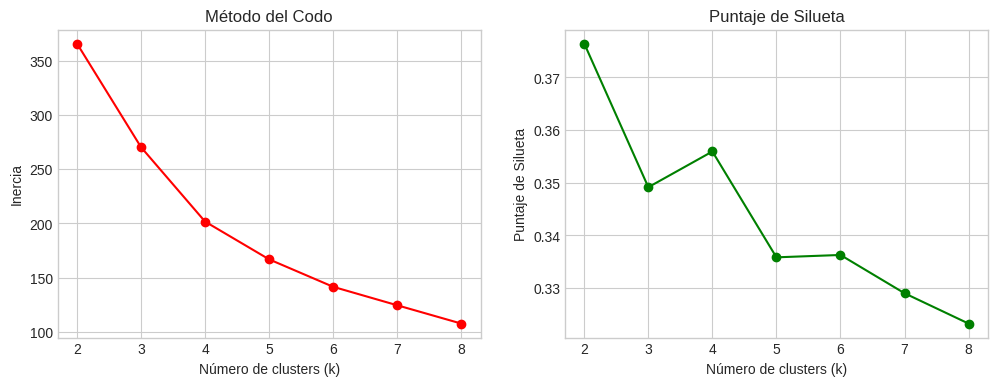


Entrenando modelo con k=4 clusters.

=== PERFIL DE CADA CLUSTER ENCONTRADO ===


,credit_terms_days,annual_revenue_potential,total_loads,total_revenue,avg_revenue_per_load,avg_weight_lbs,clientes_por_cluster
cluster,,,,,,,
0,36.25,3153267.69,398.53,1189487.05,2986.27,27652.06,36
1,40.36,2208590.15,453.09,1419707.64,3134.88,27398.82,55
2,24.06,1588794.04,418.92,1285158.90,3068.81,27313.12,48
3,46.72,3711395.74,426.80,1310372.45,3071.76,27585.25,61


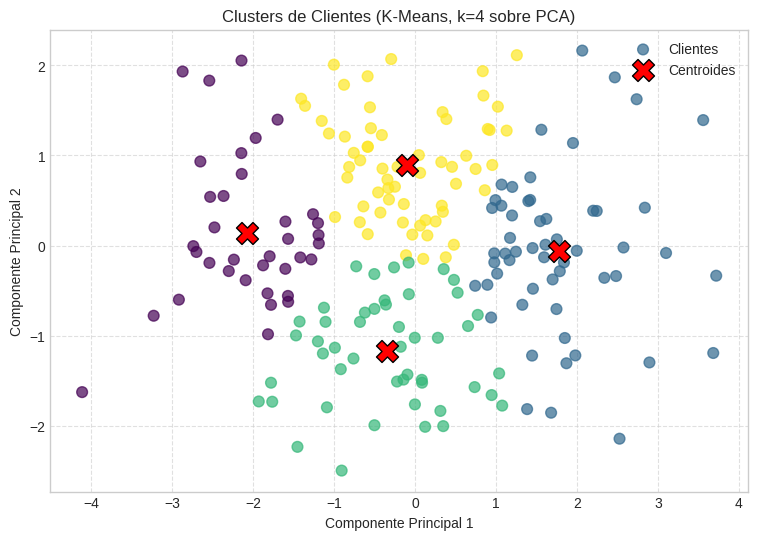

In [2]:
#Agregamos las métricas de cargas por cliente
envios_cliente = (
    df_loads.groupby('customer_id')
    .agg(total_loads=('load_id', 'count'), # Cuenta el número total de cargas por cliente
         total_revenue=('revenue', 'sum'), # Suma el ingreso total generado por el cliente
         avg_revenue_per_load=('revenue', 'mean'), # Calcula el ingreso promedio por carga
         avg_weight_lbs=('weight_lbs', 'mean'), # Calcula el peso promedio de las cargas
    )
    .reset_index() # Convierte 'customer_id' de índice a columna normal
)
# Unimos con la tabla de clientes
df_clustering = pd.merge(
    df_customers, envios_cliente, on='customer_id', how='left'
).fillna(0)

features_clustering = [
    'credit_terms_days',
    'annual_revenue_potential',
    'total_loads',
    'total_revenue',
    'avg_revenue_per_load',
    'avg_weight_lbs',
]

# Estandarizamos para que las distancias no se sesguen
scaler_k = StandardScaler()
X_clientes_scaled = scaler_k.fit_transform(df_clustering[features_clustering])

# APLICAMOS PCA (Reducción de dimensionalidad antes del clustering)
# Esto filtra el "ruido" y concentra la información en 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clientes_scaled)

# Evaluación de K con Inercia (Codo) y Silueta SOBRE LOS DATOS REDUCIDOS (PCA)
inercia, siluetas = [], []
rango_k = range(2, 9)

for k in rango_k:
    km_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km_eval.fit_predict(X_pca) # Entrenamiento sobre componentes PCA
    inercia.append(km_eval.inertia_)
    siluetas.append(silhouette_score(X_pca, etiquetas))

# Gráfico del método del codo y silueta
plt.figure(figsize=(12, 4))

# Gráfico del método del codo
plt.subplot(1, 2, 1)
plt.plot(rango_k, inercia, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)

# Gráfico de Silhouette
plt.subplot(1, 2, 2)
plt.plot(rango_k, siluetas, 'go-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Puntaje de Silueta')
plt.title('Puntaje de Silueta')
plt.grid(True)
plt.show()

# Tomamos la recomendacion del profesor y hacemos el modelo final con el k=4, un poco mayor que el 2
k_optimo = 4
print(f'\nEntrenando modelo con k={k_optimo} clusters.')

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans_final.fit_predict(X_pca)

# Asignar las coordenadas PCA al dataframe
df_clustering['pca_1'] = X_pca[:, 0]
df_clustering['pca_2'] = X_pca[:, 1]

# Perfilamiento de clusters
perfiles_cluster = df_clustering.groupby('cluster')[features_clustering].mean()
perfiles_cluster['clientes_por_cluster'] = df_clustering.groupby('cluster').size()
print('\n=== PERFIL DE CADA CLUSTER ENCONTRADO ===')
display(perfiles_cluster.round(2))

# Visualización de los clusters en el espacio PCA
centroides_pca = kmeans_final.cluster_centers_

plt.figure(figsize=(9, 6))
plt.scatter(df_clustering['pca_1'], df_clustering['pca_2'], c=df_clustering['cluster'], cmap='viridis', s=60, alpha=0.7, label='Clientes')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker='X', s=250, color='red', edgecolors='black', label='Centroides')
plt.title(f'Clusters de Clientes (K-Means, k={k_optimo} sobre PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Parte 2: Detección de Anomalías - Mezclas Gaussianas Mixtas (GMM)

**Objetivo**
Entrenar un modelo probabilístico para identificar cargas sospechosas o inusuales en el sistema. Al no contar con etiquetas previas de fraude (problema no supervisado), utilizaremos un modelo de **Mezclas Gaussianas Mixtas (GMM)** para estimar la distribución normal de la operación y aislar los registros con una probabilidad de ocurrencia críticamente baja.

**Requisitos Aplicados**

* **Ingeniería de Características:** Creación de variables relacionales (`revenue_per_lb` y `revenue_per_mile`) para detectar tarifas incongruentes frente al peso o la distancia.
* **StandardScaler:** Para escalar las variables continuas antes de la estimación de densidad probabilística.
* **Definición de Umbral (Outliers):** Cálculo de la log-verosimilitud (`score_samples`) y marcado de anomalías utilizando el **percentil 1% inferior** de los datos.

---

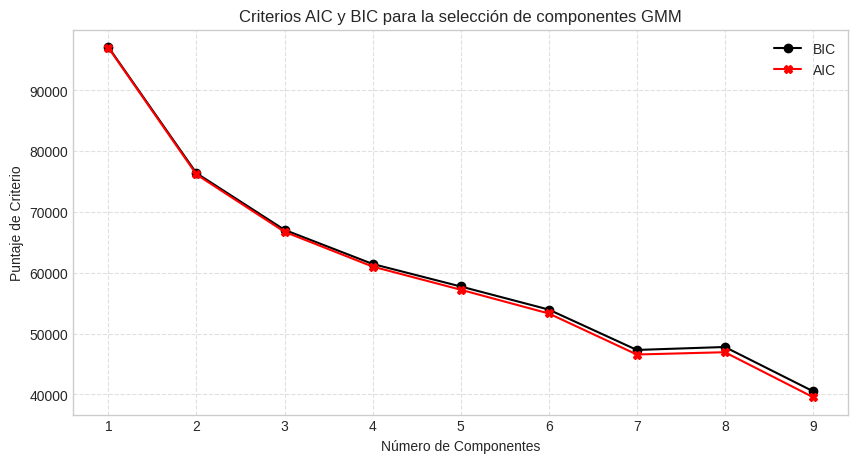

Dentro del rango evaluado, el mejor BIC se alcanza con n_components=9

Total de anomalías detectadas: 855 de 85,410 cargas (1.00%)

Comparación de promedios: cargas normales vs. anómalas


,revenue,weight_lbs,typical_distance_miles,revenue_per_lb,revenue_per_mile
es_anomalia,,,,,
False,3064.59,27538.91,1380.65,0.13,2.2
True,3975.98,21403.58,2241.49,0.25,2.0


In [3]:
# Unimos distancia típica de rutas con cada carga
df_anomalias = pd.merge(
    df_loads,
    df_routes[['route_id', 'typical_distance_miles']],
    on='route_id',
    how='left',
)

# Ingeniería de variables de negocio
df_anomalias['revenue_per_lb'] = df_anomalias['revenue'] / (df_anomalias['weight_lbs'] + 1)
df_anomalias['revenue_per_mile'] = df_anomalias['revenue'] / (df_anomalias['typical_distance_miles'] + 1)

features_gmm = [
    'revenue_per_lb',
    'revenue_per_mile',
    'weight_lbs',
    'typical_distance_miles',
]

# Eliminamos nulos en el DataFrame original para que no haya desajuste de filas luego
df_anomalias = df_anomalias.dropna(subset=features_gmm).copy()
X_gmm = df_anomalias[features_gmm]
scaler_gmm = StandardScaler()
X_gmm_scaled = scaler_gmm.fit_transform(X_gmm)

# Evaluación de componentes con AIC y BIC
# Muestreo para agilizar el cálculo (usamos max 10,000 registros para evaluar)
if len(X_gmm_scaled) > 10000:
    np.random.seed(42)
    indices_muestra = np.random.choice(len(X_gmm_scaled), 10000, replace=False)
    X_eval = X_gmm_scaled[indices_muestra]
else:
    X_eval = X_gmm_scaled

# Calcular AIC y BIC para diferentes números de componentes
n_components_range = range(1, 10)
aics = []
bics = []
for n in n_components_range:
    gmm_temp = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm_temp.fit(X_eval)
    aics.append(gmm_temp.aic(X_eval))
    bics.append(gmm_temp.bic(X_eval))

# Graficar los resultados
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bics, label='BIC', marker='o', color='black')
plt.plot(n_components_range, aics, label='AIC', marker='X', color='red')
plt.xlabel('Número de Componentes')
plt.ylabel('Puntaje de Criterio')
plt.title('Criterios AIC y BIC para la selección de componentes GMM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Selección objetiva del número de componentes: usamos el mínimo de BIC
n_components_optimo = n_components_range[np.argmin(bics)]
print(f"Dentro del rango evaluado, el mejor BIC se alcanza con n_components={n_components_optimo}")

# Ajuste de Mezclas Gaussianas con el valor óptimo
gmm = GaussianMixture(n_components=n_components_optimo, covariance_type='full', random_state=42)
gmm.fit(X_gmm_scaled)

# Cálculo de log-densidad y umbral al 1%
df_anomalias['log_probabilidad'] = gmm.score_samples(X_gmm_scaled)
umbral_corte = np.percentile(df_anomalias['log_probabilidad'], 1.0)
df_anomalias['es_anomalia'] = (df_anomalias['log_probabilidad'] < umbral_corte)

# Impresión en texto
total_anom = df_anomalias['es_anomalia'].sum()
pct_anom = 100 * total_anom / len(df_anomalias)
print(f'\nTotal de anomalías detectadas: {total_anom:,} de {len(df_anomalias):,} cargas ({pct_anom:.2f}%)')

# Comparamos el promedio de las cargas anómalas contra el promedio general
comparacion_anomalias = df_anomalias.groupby('es_anomalia')[
    ['revenue', 'weight_lbs', 'typical_distance_miles', 'revenue_per_lb', 'revenue_per_mile']
].mean()
print('\nComparación de promedios: cargas normales vs. anómalas')
display(comparacion_anomalias.round(2))


Muestra de cargas marcadas como anomalía


,load_id,revenue,weight_lbs,typical_distance_miles,revenue_per_lb,revenue_per_mile
187,LOAD00000188,7156.57,10683,2623,0.669840,2.727351
308,LOAD00000309,2152.64,11063,720,0.194563,2.985631
512,LOAD00000513,4446.45,35842,3141,0.124054,1.415165
520,LOAD00000521,4731.23,42717,3141,0.110755,1.505802
527,LOAD00000528,7410.64,10790,2729,0.686743,2.714520
535,LOAD00000536,786.44,11800,262,0.066642,2.990266
735,LOAD00000736,4887.16,41870,3141,0.116719,1.555430
743,LOAD00000744,706.19,17170,262,0.041127,2.685133
816,LOAD00000817,6994.04,10058,2627,0.695302,2.661355
873,LOAD00000874,850.57,44882,547,0.018951,1.552135


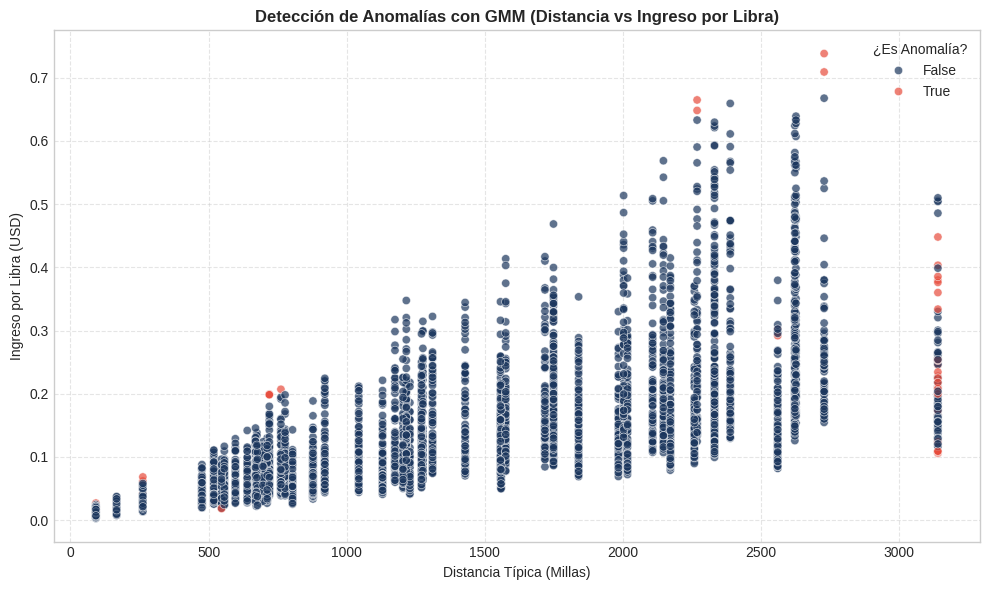

In [4]:
print('\nMuestra de cargas marcadas como anomalía')
display(
    df_anomalias[df_anomalias['es_anomalia']][
        [
            'load_id',
            'revenue',
            'weight_lbs',
            'typical_distance_miles',
            'revenue_per_lb',
            'revenue_per_mile',
        ]
    ].head(10)
)

# Gráficamos para ver visualmente
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_anomalias.sample(5000, random_state=42), # Muestreo para no saturar el gráfico
    x='typical_distance_miles',
    y='revenue_per_lb',
    hue='es_anomalia',
    palette={False: '#1B365D', True: '#E74C3C'},
    alpha=0.7
)
plt.title('Detección de Anomalías con GMM (Distancia vs Ingreso por Libra)', fontweight='bold')
plt.xlabel('Distancia Típica (Millas)')
plt.ylabel('Ingreso por Libra (USD)')
plt.legend(title='¿Es Anomalía?', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Parte 3: Sistema de Recomendación de Rutas

**Objetivo**
Sugerir a cada conductor (`driver_id`) las rutas más adecuadas según dos fuentes de contenido:
1. El **perfil de las rutas que históricamente ha operado**, extraído de `trips.csv` + `routes.csv`. Importante: `trips.csv` no tiene `route_id` directamente, sino `load_id`; la ruta se obtiene uniendo primero `trips -> loads` (por `load_id`) y luego `loads -> routes` (por `route_id`).
2. Sus **características propias**, en particular los años de experiencia del conductor (columna `years_experience` en `drivers.csv`).

**Enfoque**
Es un recomendador *basado en contenido* (no en filtrado colaborativo, que necesitaría calificaciones de otros conductores):
1. Cada ruta se representa como un vector de características (variables numéricas escaladas con `MinMaxScaler` + variables categóricas con *one-hot encoding*, p. ej. `origin_city`, `destination_state`).
2. El **perfil de cada conductor** se construye como el promedio de los vectores de las rutas que ha operado (vía `trips -> loads -> routes`); esto captura "el tipo de ruta que suele manejar".
3. Añadimos a ambos vectores una dimensión adicional que enfrenta la experiencia del conductor (escalada) contra la `typical_distance_miles` de la ruta (escalada), usada como *proxy* de dificultad/exigencia del recorrido. Así, el sistema no solo recomienda rutas parecidas a las que el conductor ya conoce, sino que también favorece rutas cuya exigencia es coherente con su experiencia.
4. Se calcula la **similitud coseno** entre el perfil de cada conductor y todas las rutas, y se recomiendan las rutas de mayor similitud que el conductor **aún no ha operado**.

In [10]:
# Columna de experiencia del conductor
_candidatas_experiencia = ['years_experience', 'driver_experience_years', 'experience_years']
col_experiencia = next((c for c in _candidatas_experiencia if c in df_drivers.columns), None)
if col_experiencia is None:
    raise KeyError(
        f'No se encontró columna de experiencia en drivers.csv. '
        f'Columnas disponibles: {df_drivers.columns.tolist()}'
    )

# Construcción del vector de contenido de cada ruta
route_id_col = 'route_id'

cols_categoricas = [
    c for c in df_routes.select_dtypes(include='object').columns if c != route_id_col
]
cols_numericas = [
    c for c in df_routes.select_dtypes(include=np.number).columns if c != route_id_col
]

print(f'Variables numéricas de ruta usadas como contenido: {cols_numericas}')
print(f'Variables categóricas de ruta usadas como contenido: {cols_categoricas}')

# Escalamos las numéricas a [0,1] (MinMax) porque para similitud coseno todas las
# dimensiones deben aportar en una escala comparable
scaler_rutas = MinMaxScaler()
routes_num_scaled = pd.DataFrame(
    scaler_rutas.fit_transform(df_routes[cols_numericas]),
    columns=cols_numericas,
    index=df_routes[route_id_col],
)

# One-hot encoding de las categóricas (tipo de ruta, región, etc.)
if cols_categoricas:
    routes_cat_encoded = pd.get_dummies(
        df_routes.set_index(route_id_col)[cols_categoricas]
    )
else:
    routes_cat_encoded = pd.DataFrame(index=df_routes[route_id_col])

# Vector de contenido final de cada ruta (antes de agregar el proxy de dificultad)
route_content = pd.concat([routes_num_scaled, routes_cat_encoded], axis=1)

# Proxy de dificultad/exigencia de la ruta = distancia típica escalada (ya está en
# routes_num_scaled si typical_distance_miles existe; si no, se calcula aparte)
if 'typical_distance_miles' in cols_numericas:
    route_content['dificultad_proxy'] = routes_num_scaled['typical_distance_miles']
else:
    route_content['dificultad_proxy'] = 0.0

# Perfil de contenido de cada conductor (promedio de las rutas operadas)

trips_con_ruta = pd.merge(
    df_trips[['trip_id', 'driver_id', 'load_id']],
    df_loads[['load_id', route_id_col]],
    on='load_id',
    how='left',
).dropna(subset=[route_id_col])
trips_con_ruta = pd.merge(trips_con_ruta, df_routes[[route_id_col]], on=route_id_col, how='inner')
trips_con_contenido = trips_con_ruta.join(route_content.drop(columns='dificultad_proxy'), on=route_id_col)

driver_profile = (
    trips_con_contenido.groupby('driver_id')[route_content.drop(columns='dificultad_proxy').columns]
    .mean()
)

# Reindexamos para incluir también a conductores sin viajes registrados (perfil neutro = 0)
driver_profile = driver_profile.reindex(df_drivers['driver_id']).fillna(0)

# Agregamos la experiencia del conductor escalada [0,1] como la dimensión que se
# enfrenta al 'dificultad_proxy' de las rutas
scaler_exp = MinMaxScaler()
experiencia_escalada = pd.Series(
    scaler_exp.fit_transform(df_drivers[[col_experiencia]]).ravel(),
    index=df_drivers['driver_id'],
    name='dificultad_proxy',
)
driver_profile['dificultad_proxy'] = experiencia_escalada

# Alineamos el orden de columnas entre conductores y rutas para que la similitud
# coseno compare cada dimensión con su contraparte correcta
route_content = route_content[driver_profile.columns]

# Similitud coseno conductor <-> ruta
similitud = cosine_similarity(driver_profile.values, route_content.values)
df_similitud = pd.DataFrame(
    similitud, index=driver_profile.index, columns=route_content.index
)

# Función de recomendación: rutas mejor rankeadas por afinidad con el perfil -
# Nota: en este dataset solo hay ~58 rutas y cada conductor acumula cientos de
# viajes, así que casi todos terminan operando el catálogo completo de rutas.
# Por eso NO excluimos por defecto las rutas ya operadas (si lo hiciéramos, la
# mayoría de conductores se quedarían sin recomendaciones); en cambio, rankeamos
# TODAS las rutas por afinidad con el perfil del conductor. Se deja
# la opción de excluir las operadas (excluir_operadas=True)
rutas_operadas_por_conductor = trips_con_ruta.groupby('driver_id')[route_id_col].apply(set)

def recomendar_rutas(driver_id, top_n=5, excluir_operadas=False):
    """Devuelve las top_n rutas recomendadas para un conductor, rankeadas por
    similitud de contenido con su perfil histórico + experiencia."""
    if driver_id not in df_similitud.index:
        raise ValueError(f'driver_id {driver_id} no encontrado en drivers.csv')

    scores = df_similitud.loc[driver_id].copy()
    if excluir_operadas:
        ya_operadas = rutas_operadas_por_conductor.get(driver_id, set())
        candidatas = scores.drop(index=[r for r in ya_operadas if r in scores.index])
        if candidatas.empty:  # si ya operó todo el catálogo, no excluimos
            candidatas = scores
        scores = candidatas

    top = scores.sort_values(ascending=False).head(top_n).reset_index()
    top.columns = ['route_id', 'score_similitud']
    top = top.merge(df_routes, on='route_id', how='left')
    return top

# Ejemplo de recomendación para algunos conductores (uno por nivel de experiencia)
ejemplo_drivers = (
    df_drivers.sort_values(col_experiencia)
    .iloc[[0, len(df_drivers) // 2, -1]]['driver_id']
    .tolist()
)

for d in ejemplo_drivers:
    exp = df_drivers.loc[df_drivers['driver_id'] == d, col_experiencia].values[0]
    print(f'\nRecomendaciones para {d} (experiencia: {exp} años):')
    display(recomendar_rutas(d, top_n=5)[['route_id', 'score_similitud'] + cols_categoricas + cols_numericas])

# Visualización: experiencia del conductor vs. distancia típica de las rutas
# recomendadas en el top 1, para verificar coherencia del sistema
top1_por_conductor = []
for d in df_drivers['driver_id']:
    rec = recomendar_rutas(d, top_n=1)
    if len(rec):
        top1_por_conductor.append({
            'driver_id': d,
            'experiencia_anios': df_drivers.loc[df_drivers['driver_id'] == d, col_experiencia].values[0],
            'distancia_ruta_recomendada': rec['typical_distance_miles'].iloc[0] if 'typical_distance_miles' in rec.columns else np.nan,
        })
df_top1 = pd.DataFrame(top1_por_conductor)

Variables numéricas de ruta usadas como contenido: ['typical_distance_miles', 'base_rate_per_mile', 'fuel_surcharge_rate', 'typical_transit_days']
Variables categóricas de ruta usadas como contenido: ['origin_city', 'origin_state', 'destination_city', 'destination_state']

Recomendaciones para DRV00053 (experiencia: 2 años):


,route_id,score_similitud,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00048,0.663691,Columbus,OH,Portland,OR,2332,2.69,0.34,4
1,RTE00044,0.619286,Charlotte,NC,Portland,OR,2627,2.69,0.31,4
2,RTE00003,0.613431,Chicago,IL,Los Angeles,CA,2003,2.55,0.29,3
3,RTE00046,0.594874,Columbus,OH,Los Angeles,CA,2269,2.74,0.22,3
4,RTE00040,0.593126,Minneapolis,MN,Los Angeles,CA,1749,2.38,0.30,3



Recomendaciones para DRV00068 (experiencia: 14 años):


,route_id,score_similitud,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00025,0.377012,Miami,FL,Seattle,WA,3141,1.65,0.18,5
1,RTE00016,0.335005,Philadelphia,PA,Seattle,WA,2729,2.50,0.17,4
2,RTE00037,0.331316,Las Vegas,NV,New York,NY,2561,1.52,0.21,4
3,RTE00042,0.327239,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
4,RTE00032,0.303982,Portland,OR,Detroit,MI,2259,1.99,0.20,3



Recomendaciones para DRV00140 (experiencia: 25 años):


,route_id,score_similitud,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00025,0.377012,Miami,FL,Seattle,WA,3141,1.65,0.18,5
1,RTE00016,0.335005,Philadelphia,PA,Seattle,WA,2729,2.50,0.17,4
2,RTE00037,0.331316,Las Vegas,NV,New York,NY,2561,1.52,0.21,4
3,RTE00042,0.327239,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
4,RTE00032,0.303982,Portland,OR,Detroit,MI,2259,1.99,0.20,3
